## Import Facial Expressions Dataset from Kaggle

In [ ]:
# Import Facial Expressions Dataset

import kagglehub

# Download latest version
path = kagglehub.dataset_download("msambare/fer2013")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'fer2013' dataset.
Path to dataset files: /kaggle/input/fer2013


In [ ]:
import os
os.listdir(path)

['test', 'train']

In [ ]:
# Show the classes in train set
train_dir = os.path.join(path, "train")
test_dir  = os.path.join(path, "test")

print(os.listdir(train_dir))

['surprise', 'fear', 'angry', 'neutral', 'sad', 'disgust', 'happy']


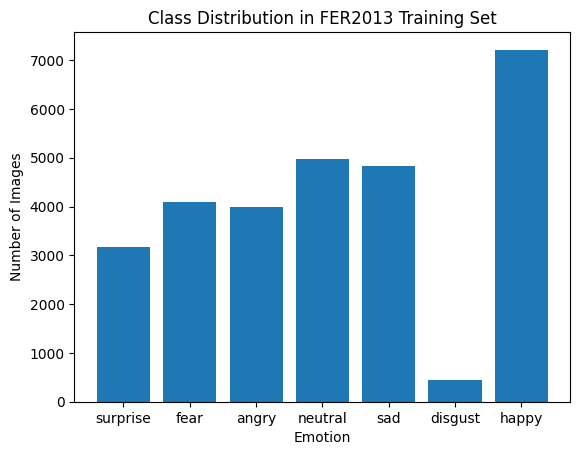

In [ ]:
# Plot Class distribution
import matplotlib.pyplot as plt
count=0
class_count={}
for emotion in os.listdir(train_dir):
  for img in os.listdir(os.path.join(train_dir, emotion)):
    count+=1
  class_count[emotion] = count
  count=0

plt.bar(class_count.keys(), class_count.values())
plt.title("Class Distribution in FER2013 Training Set")
plt.xlabel("Emotion")
plt.ylabel("Number of Images")
plt.show()

In [ ]:
class_count

{'surprise': 3171,
 'fear': 4097,
 'angry': 3995,
 'neutral': 4965,
 'sad': 4830,
 'disgust': 436,
 'happy': 7215}

In [ ]:
emotion_labels = {
    'angry': 0,
    'disgust': 1,
    'fear': 2,
    'happy': 3,
    'sad': 4,
    'surprise': 5,
    'neutral': 6
}


## Prerocess the data and split it to X,y train and X,y test

In [ ]:
# PREPROCESSING THE IMAGES & SPLIT INTO X TRAIN AND Y TRAIN
import cv2
import numpy as np

x_train = []
y_train=[]

for emotion, label in emotion_labels.items():
  for img in os.listdir(os.path.join(train_dir, emotion)):
    img_path = os.path.join(train_dir, emotion, img)
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
      continue
    img= cv2.resize(img, (48,48))
    img = img/255.0        # Normalize [0,1] for the classifier
    img = np.expand_dims(img, axis=-1)

    x_train.append(img)
    y_train.append(label)

x_train = np.array(x_train)
y_train = np.array(y_train)

print(x_train.shape, y_train.shape)

(28709, 48, 48, 1) (28709,)


In [ ]:
# PREPROCESSING THE IMAGES & SPLIT INTO X TEST AND Y TEST

x_test = []
y_test=[]

for emotion, label in emotion_labels.items():
  for img in os.listdir(os.path.join(test_dir, emotion)):
    img_path = os.path.join(test_dir, emotion, img)
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
      continue
    img= cv2.resize(img, (48,48))
    img = img/255.0        # Normalize [0,1] for the classifier
    img = np.expand_dims(img, axis=-1)

    x_test.append(img)
    y_test.append(label)

x_test = np.array(x_test)
y_test = np.array(y_test)

print(x_test.shape, y_test.shape)

(7178, 48, 48, 1) (7178,)


In [ ]:
# Extract Disgust images from x_train
disgust_images = x_train[y_train == emotion_labels['disgust']]

print(disgust_images.shape)


(436, 48, 48, 1)


In [ ]:
#Normalize disgust images to [-1,1] for GANs
disgust_images=disgust_images/2.0 -1.0

In [ ]:
#Data Augmentation for better results (just for training GANs )
import tensorflow as tf
from tensorflow.keras import layers

augmenter = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.05),
    layers.RandomTranslation(0.05, 0.05),
])
augmented_images = augmenter(disgust_images, training=True)
augmented_images = augmented_images.numpy()


In [ ]:
disgust_augmented=np.concatenate([augmented_images,disgust_images],axis=0)
disgust_augmented.shape

(872, 48, 48, 1)

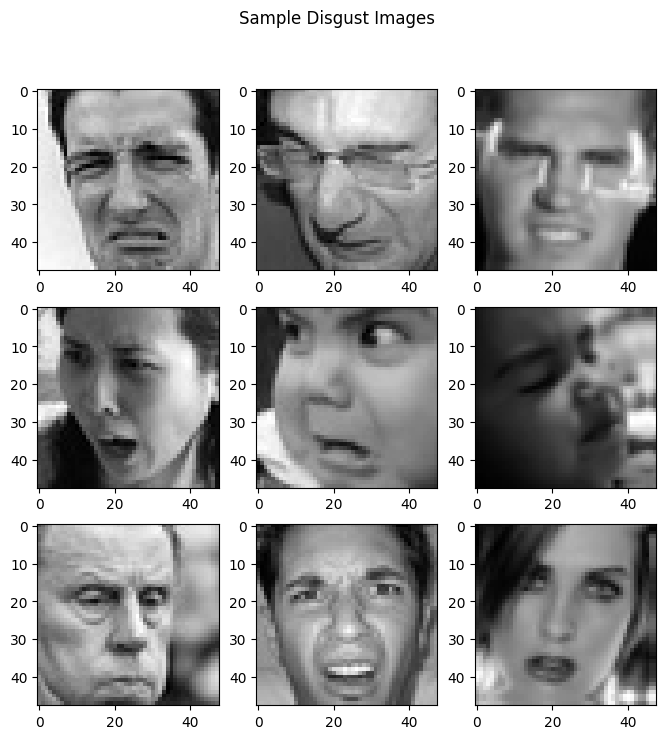

In [ ]:
# Preview on images
import matplotlib.pyplot as plt

plt.figure(figsize=(8,8))
random =disgust_augmented[ np.random.randint(0, disgust_augmented.shape[0], 9)]
for i ,img in enumerate(random):
    plt.subplot(3,3,i+1)
    plt.imshow(img.squeeze(), cmap='gray')
plt.suptitle("Sample Disgust Images")
plt.show()


## Vanilla GAN Implementation

In [ ]:
# Vanilla GAN
import tensorflow as tf
from tensorflow.keras import layers

def build_generator():
  model = tf.keras.Sequential([
        layers.Dense(256,input_dim=100),
        layers.LeakyReLU(0.2),

        layers.Dense(512),
        layers.LeakyReLU(0.2),

        layers.Dense(48*48*1, activation='tanh'),
        layers.Reshape((48, 48, 1))
    ])
  return model


In [ ]:
def build_discriminator():
    model = tf.keras.Sequential([
        layers.Flatten(input_shape=(48,48,1)),
        layers.Dense(512),
        layers.LeakyReLU(0.2),
        layers.Dense(256),
        layers.LeakyReLU(0.2),
        layers.Dense(1, activation='sigmoid')
    ])
    return model

In [ ]:
generator = build_generator()
discriminator = build_discriminator()

discriminator.compile(
    optimizer=tf.keras.optimizers.Adam(0.0005, 0.5),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

discriminator.trainable = False


In [ ]:
noise = layers.Input(shape=(100,)) # random noise the input for the generator
generated_image = generator(noise)
validity = discriminator(generated_image)

gan = tf.keras.Model(noise, validity)
gan.compile(
    optimizer=tf.keras.optimizers.Adam(0.001, 0.5),
    loss='binary_crossentropy'
)

In [ ]:
import random

epochs = 1500
batch_size = 32
half_batch = batch_size // 2

for epoch in range(epochs):
    # Train Discriminator
    # Make sure discriminator is trainable
    discriminator.trainable = True

    # pick random real images from the dataset
    idx = np.random.randint(0, disgust_augmented.shape[0], half_batch)
    real_imgs = disgust_augmented[idx]
    # fake images from the generator
    noise = np.random.normal(0, 1, (half_batch, 100))
    fake_imgs = generator.predict(noise, verbose=0)

    # Train the discriminator on both fake and real images
    d_loss_real = discriminator.train_on_batch(real_imgs, np.ones((half_batch, 1)))
    d_loss_fake = discriminator.train_on_batch(fake_imgs, np.zeros((half_batch, 1)))

    # Make discriminator non-trainable for generator training
    discriminator.trainable = False

    #Train Generator
    noise = np.random.normal(0, 1, (batch_size, 100))
    g_loss = gan.train_on_batch(noise, np.ones((batch_size, 1)))

    if epoch % 100 == 0:
        print(f"{epoch} [D loss: {0.5*(d_loss_real[0]+d_loss_fake[0])}] [G loss: {g_loss}]")

0 [D loss: 0.2828308641910553] [G loss: 1.1723718643188477]
50 [D loss: 1.0561600923538208] [G loss: 1.139829158782959]
100 [D loss: 0.9304670691490173] [G loss: 1.0017732381820679]
150 [D loss: 0.8788449764251709] [G loss: 0.9963858723640442]
200 [D loss: 0.857550323009491] [G loss: 1.0146821737289429]
250 [D loss: 0.8449879288673401] [G loss: 1.0096784830093384]
300 [D loss: 0.8349572420120239] [G loss: 0.98041832447052]
350 [D loss: 0.8341251611709595] [G loss: 0.9772911667823792]
400 [D loss: 0.8250012397766113] [G loss: 0.9598889946937561]
450 [D loss: 0.8279243111610413] [G loss: 0.9597558379173279]
500 [D loss: 0.8187801837921143] [G loss: 0.9432255029678345]
550 [D loss: 0.8094841241836548] [G loss: 0.9307101368904114]
600 [D loss: 0.8192242383956909] [G loss: 0.93976891040802]
650 [D loss: 0.8174920082092285] [G loss: 0.9243453741073608]
700 [D loss: 0.811928391456604] [G loss: 0.9125677943229675]
750 [D loss: 0.8058613538742065] [G loss: 0.9034312963485718]
800 [D loss: 0.800

82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


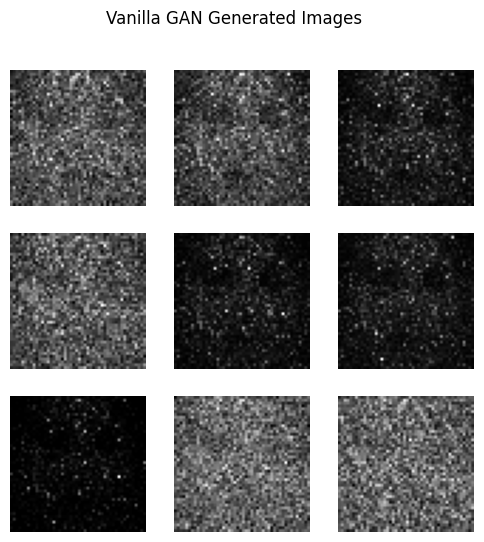

In [ ]:
# Ganerate and save samples from Vanilla GAN
num_gen = 2600
noise = np.random.normal(0, 1, (num_gen, 100))
vanilla_gen_images = generator.predict(noise)
vanilla_gen_images = (vanilla_gen_images + 1) * 127.5  # scale images to[0,1] to match the classifier
vanilla_gen_images = vanilla_gen_images.astype("uint8")

plt.figure(figsize=(6,6))
for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(vanilla_gen_images[i].squeeze(), cmap='gray')
    plt.axis('off')
plt.suptitle("Vanilla GAN Generated Images")
plt.show()

In [ ]:
# Merge the generated images with the original x_train

disgust_label=emotion_labels['disgust']

vanilla_gen_labels=np.full((vanilla_gen_images.shape[0],) , disgust_label)
x_train_vanilla=np.concatenate([x_train,vanilla_gen_images])
y_train_vanilla=np.concatenate([y_train,vanilla_gen_labels ])
print(x_train.shape)
print(x_train_vanilla.shape)


(28709, 48, 48, 1)
(31309, 48, 48, 1)


## DCGAN Implementation

In [ ]:
# DCGAN
def build_dcgan_generator():
    model = tf.keras.Sequential()

    model.add(layers.Dense(6*6*256, input_dim=100))
    model.add(layers.Reshape((6, 6, 256)))
    model.add(layers.BatchNormalization())
    model.add(layers.ReLU())

    model.add(layers.UpSampling2D())
    model.add(layers.Conv2D(128, kernel_size=3, padding="same"))
    model.add(layers.BatchNormalization())
    model.add(layers.ReLU())

    model.add(layers.UpSampling2D())
    model.add(layers.Conv2D(64, kernel_size=3, padding="same"))
    model.add(layers.BatchNormalization())
    model.add(layers.ReLU())

    model.add(layers.UpSampling2D())
    model.add(layers.Conv2D(1, kernel_size=3, padding="same", activation="tanh"))

    return model

In [ ]:
def build_dcgan_discriminator():
    model = tf.keras.Sequential()

    model.add(layers.Conv2D(64, kernel_size=3, strides=2, padding="same",
                            input_shape=(48, 48, 1)))
    model.add(layers.LeakyReLU(0.2))
    model.add(layers.Dropout(0.3))

    model.add(layers.Conv2D(128, kernel_size=3, strides=2, padding="same"))
    model.add(layers.LeakyReLU(0.2))
    model.add(layers.Dropout(0.3))

    model.add(layers.Conv2D(256, kernel_size=3, strides=2, padding="same"))
    model.add(layers.LeakyReLU(0.2))
    model.add(layers.Dropout(0.3))

    model.add(layers.Flatten())
    model.add(layers.Dense(1, activation="sigmoid"))

    return model


In [ ]:
dcgan_generator = build_dcgan_generator()
dcgan_discriminator = build_dcgan_discriminator()

dcgan_discriminator.compile(
    optimizer=tf.keras.optimizers.Adam(0.0002, 0.5),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

dcgan_discriminator.trainable = False
dcgan_generator.trainable = True

In [ ]:
noise_dcgan = layers.Input(shape=(100,))
generated_img_dcgan = dcgan_generator(noise_dcgan)
validity_dcgan = dcgan_discriminator(generated_img_dcgan)

dcgan = tf.keras.Model(noise_dcgan, validity_dcgan)
dcgan.compile(
    optimizer=tf.keras.optimizers.Adam(0.0002, 0.5),
    loss="binary_crossentropy"
)


In [ ]:
epochs = 2500
batch_size = 32
half_batch = batch_size // 2

for epoch in range(epochs):
    # same as what we did in vanilla gan
    dcgan_discriminator.trainable = True

    # pick random real images from the dataset
    idx = np.random.randint(0, disgust_augmented.shape[0], half_batch)
    real_imgs = disgust_augmented[idx]

    noise = np.random.normal(0, 1, (half_batch, 100))
    fake_imgs = dcgan_generator.predict(noise, verbose=0)

    d_loss_real = dcgan_discriminator.train_on_batch(
        real_imgs, np.ones((half_batch, 1))
    )
    d_loss_fake = dcgan_discriminator.train_on_batch(
        fake_imgs, np.zeros((half_batch, 1))
    )

    dcgan_discriminator.trainable = False

    noise = np.random.normal(0, 1, (batch_size, 100))
    g_loss = dcgan.train_on_batch(
        noise, np.ones((batch_size, 1))
    )

    if epoch % 100 == 0:
        print(f"{epoch} [D loss: {0.5*(d_loss_real[0]+d_loss_fake[0])}] [G loss: {g_loss}]")


0 [D loss: 0.7089213132858276] [G loss: 0.619118869304657]
100 [D loss: 0.46931278705596924] [G loss: 0.055155154317617416]
200 [D loss: 0.5123867988586426] [G loss: 0.17688308656215668]
300 [D loss: 0.3810715675354004] [G loss: 0.11817223578691483]
400 [D loss: 0.34548264741897583] [G loss: 0.08981914073228836]
500 [D loss: 0.3942643105983734] [G loss: 0.14579790830612183]
600 [D loss: 0.3965592384338379] [G loss: 0.19149057567119598]
700 [D loss: 0.3569827377796173] [G loss: 0.19510537385940552]
800 [D loss: 0.32272788882255554] [G loss: 0.1728188693523407]
900 [D loss: 0.3297896981239319] [G loss: 0.18955208361148834]
1000 [D loss: 0.35216885805130005] [G loss: 0.19708354771137238]
1100 [D loss: 0.39240509271621704] [G loss: 0.22426660358905792]
1200 [D loss: 0.4227730631828308] [G loss: 0.25881248712539673]
1300 [D loss: 0.44613516330718994] [G loss: 0.29146966338157654]
1400 [D loss: 0.4645308256149292] [G loss: 0.3183019161224365]
1500 [D loss: 0.47985774278640747] [G loss: 0.340

82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


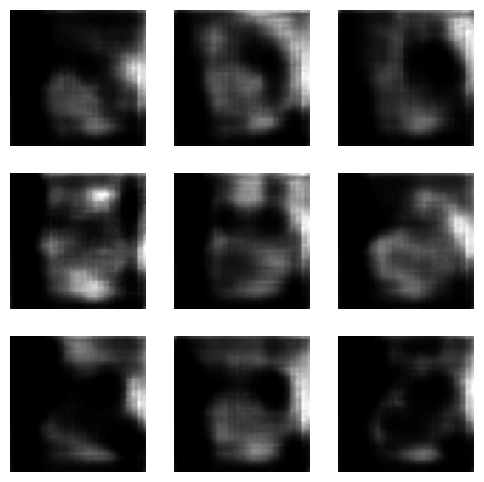

In [ ]:
# Visualize the generated images
num_gen = 2600
noise = np.random.normal(0, 1, (num_gen, 100))
dcgan_gen_images = dcgan_generator.predict(noise)

dcgan_gen_images = (dcgan_gen_images + 1) * 127.5
dcgan_gen_images = dcgan_gen_images.astype("uint8")

plt.figure(figsize=(6,6))
for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(dcgan_gen_images[i].squeeze(), cmap='gray')
    plt.axis('off')

In [ ]:
# Merge the generated images with the original

dcgan_gen_labels=np.full((dcgan_gen_images.shape[0],) , disgust_label) # to create labels for the new images
x_train_dcgan=np.concatenate([x_train,dcgan_gen_images])
y_train_dcgan=np.concatenate([y_train,dcgan_gen_labels ])

print(x_train.shape)
print(x_train_dcgan.shape)


(28709, 48, 48, 1)
(31309, 48, 48, 1)


## CNN Model Implementation

In [39]:
# CNN Classification Model
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

model = Sequential([
    Conv2D(32,(3,3), activation='relu',input_shape=(48,48,1)),
    MaxPooling2D(2,2),

    Conv2D(64,(3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128,(3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(7, activation='softmax')

])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [40]:
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy',metrics=['accuracy'])

In [41]:
# To verify
print(x_train.shape, y_train.shape)
print(np.unique(y_train))


(28709, 48, 48, 1) (28709,)
[0 1 2 3 4 5 6]


## First, train the CNN on the original data

In [43]:
history = model.fit(x_train,y_train, epochs=20,validation_data=(x_test,y_test), batch_size=64)


Epoch 1/20
449/449 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.5275 - loss: 1.2403 - val_accuracy: 0.5187 - val_loss: 1.2484
Epoch 2/20
449/449 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.5504 - loss: 1.2031 - val_accuracy: 0.5350 - val_loss: 1.2086
Epoch 3/20
449/449 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.5591 - loss: 1.1679 - val_accuracy: 0.5418 - val_loss: 1.2021
Epoch 4/20
449/449 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.5633 - loss: 1.1428 - val_accuracy: 0.5417 - val_loss: 1.1970
Epoch 5/20
449/449 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.5796 - loss: 1.1065 - val_accuracy: 0.5447 - val_loss: 1.1823
Epoch 6/20
449/449 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.5925 - loss: 1.0790 - val_accuracy: 0.5451 - val_loss: 1.1764
Epoch 7/20
449/449 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.6049 - loss: 1.0354 - val_accuracy: 0.5515 - val_loss: 1.2021
Epoch 8/20
449/449 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.6138 - loss: 1.0125 - val_accuracy: 0.

In [44]:
from sklearn.metrics import classification_report

y_pred = np.argmax(model.predict(x_test), axis=1)

print("Original imbalance dataset\n",classification_report(
    y_test,
    y_pred,
    target_names=emotion_labels.keys()
))


225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
Original imbalance dataset
               precision    recall  f1-score   support

       angry       0.49      0.49      0.49       958
     disgust       0.75      0.30      0.43       111
        fear       0.39      0.33      0.36      1024
       happy       0.75      0.79      0.77      1774
         sad       0.42      0.50      0.46      1247
    surprise       0.76      0.66      0.71       831
     neutral       0.53      0.53      0.53      1233

    accuracy                           0.57      7178
   macro avg       0.58      0.51      0.53      7178
weighted avg       0.57      0.57      0.57      7178



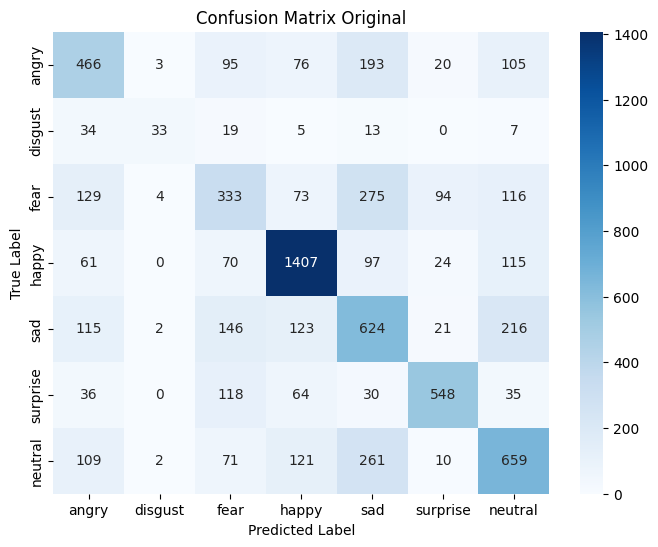

In [45]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=emotion_labels.keys(),
    yticklabels=emotion_labels.keys()
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix Original")
plt.show()


## Second, train the CNN on the data+vanilla generated images

In [ ]:
history = model.fit(x_train_vanilla,y_train_vanilla, epochs=20,validation_data=(x_test,y_test), batch_size=64)

Epoch 1/20
490/490 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.8921 - loss: 0.2687 - val_accuracy: 0.5695 - val_loss: 2.9725
Epoch 2/20
490/490 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.8911 - loss: 0.2715 - val_accuracy: 0.5706 - val_loss: 3.1849
Epoch 3/20
490/490 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.8875 - loss: 0.2856 - val_accuracy: 0.5667 - val_loss: 2.8980
Epoch 4/20
490/490 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.8847 - loss: 0.2872 - val_accuracy: 0.5776 - val_loss: 2.9414
Epoch 5/20
490/490 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.8946 - loss: 0.2624 - val_accuracy: 0.5614 - val_loss: 3.0842
Epoch 6/20
490/490 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.8975 - loss: 0.2606 - val_accuracy: 0.5651 - val_loss: 3.0499
Epoch 7/20
490/490 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.8959 - loss: 0.2549 - val_accuracy: 0.5748 - val_loss: 3.1043
Epoch 8/20
490/490 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.8951 - loss: 0.2590 - val_accuracy: 0.

In [ ]:
from sklearn.metrics import classification_report

y_pred = np.argmax(model.predict(x_test), axis=1)

print("Balanced with Vanilla GAN\n",classification_report(
    y_test,
    y_pred,
    target_names=emotion_labels.keys()
))


225/225 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Balanced with Vanilla GAN
               precision    recall  f1-score   support

       angry       0.46      0.47      0.47       958
     disgust       0.84      0.46      0.59       111
        fear       0.40      0.41      0.41      1024
       happy       0.74      0.79      0.77      1774
         sad       0.43      0.41      0.42      1247
    surprise       0.77      0.71      0.74       831
     neutral       0.50      0.50      0.50      1233

    accuracy                           0.56      7178
   macro avg       0.59      0.54      0.56      7178
weighted avg       0.57      0.56      0.56      7178



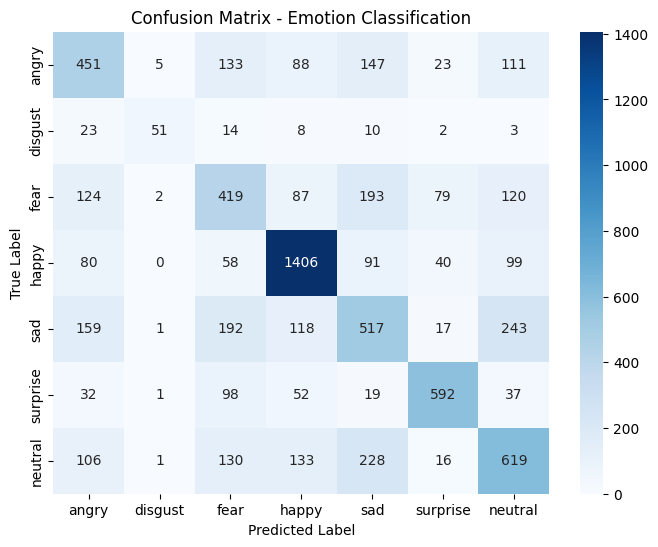

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=emotion_labels.keys(),
    yticklabels=emotion_labels.keys()
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix Vanilla GAN")
plt.show()


## Last, train the CNN on the data+ dcgan generated images

In [ ]:
history = model.fit(x_train_dcgan,y_train_dcgan, epochs=20,validation_data=(x_test,y_test), batch_size=64)

Epoch 1/20
490/490 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.8945 - loss: 0.2906 - val_accuracy: 0.5645 - val_loss: 3.3297
Epoch 2/20
490/490 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9028 - loss: 0.2486 - val_accuracy: 0.5683 - val_loss: 3.5652
Epoch 3/20
490/490 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9110 - loss: 0.2215 - val_accuracy: 0.5712 - val_loss: 3.3586
Epoch 4/20
490/490 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9076 - loss: 0.2314 - val_accuracy: 0.5727 - val_loss: 3.5511
Epoch 5/20
490/490 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9077 - loss: 0.2320 - val_accuracy: 0.5731 - val_loss: 3.4948
Epoch 6/20
490/490 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.9083 - loss: 0.2279 - val_accuracy: 0.5716 - val_loss: 3.3544
Epoch 7/20
490/490 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9107 - loss: 0.2259 - val_accuracy: 0.5711 - val_loss: 3.6542
Epoch 8/20
490/490 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9094 - loss: 0.2341 - val_accuracy: 0.

In [ ]:
from sklearn.metrics import classification_report

y_pred = np.argmax(model.predict(x_test), axis=1)

print("Balanced with DCGAN \n\n",classification_report(
    y_test,
    y_pred,
    target_names=emotion_labels.keys()
))


225/225 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Balanced with DCGAN 

               precision    recall  f1-score   support

       angry       0.47      0.46      0.46       958
     disgust       0.82      0.45      0.58       111
        fear       0.44      0.37      0.40      1024
       happy       0.75      0.79      0.77      1774
         sad       0.46      0.42      0.44      1247
    surprise       0.70      0.75      0.72       831
     neutral       0.49      0.56      0.52      1233

    accuracy                           0.57      7178
   macro avg       0.59      0.54      0.56      7178
weighted avg       0.57      0.57      0.57      7178



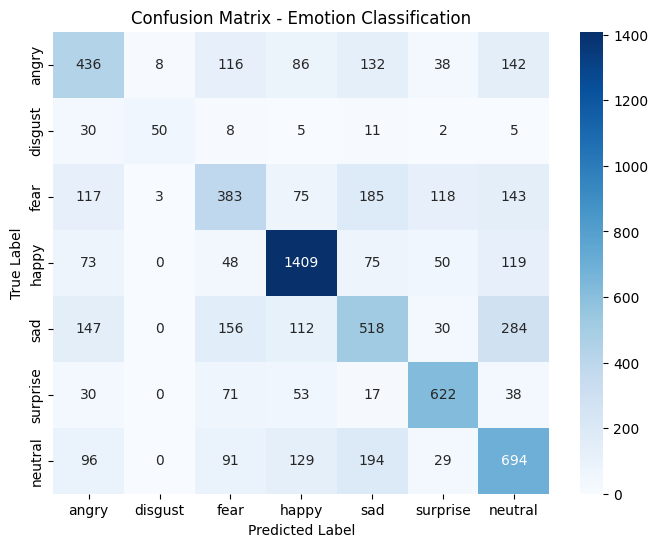

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=emotion_labels.keys(),
    yticklabels=emotion_labels.keys()
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix DCGAN")
plt.show()
